In [5]:
import pandas as pd
import sys

# --- 配置 ---
FILE_NAME = 'combined_test_data.parquet'
# ---

def load_parquet_data(file_path):
    """
    尝试读取指定的 Parquet 文件并返回一个 DataFrame。
    """
    print(f"Attempting to read file: {file_path}")
    
    try:
        # pd.read_parquet 是核心命令
        df = pd.read_parquet(file_path)
        
        print("✅ File read successfully.")
        return df
        
    except FileNotFoundError:
        print(f"❌ ERROR: File not found at '{file_path}'")
        print("Please check if the file name and path are correct.")
        return None
    except Exception as e:
        print(f"❌ ERROR: An unexpected error occurred while reading the file.")
        print(f"Error details: {e}")
        return None

# --- 脚本主程序 ---

# 调用函数来读取数据
data_frame = load_parquet_data(FILE_NAME)

# 如果数据读取成功，则显示一些基本信息
if data_frame is not None:
    print("\n--- Data Overview ---")
    
    # 显示数据的前5行
    print("\n[Data Head (first 5 rows)]:")
    print(data_frame.head())
    
    # 显示数据的基本信息（列名、非空计数、类型）
    print("\n[Data Info]:")
    data_frame.info()
    
    # 显示数据的维度（行数, 列数）
    print(f"\n[Data Shape]:")
    print(f"Rows: {data_frame.shape[0]}, Columns: {data_frame.shape[1]}")

Attempting to read file: combined_test_data.parquet
✅ File read successfully.

--- Data Overview ---

[Data Head (first 5 rows)]:
                                      original_image  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                  conditioning_image  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                            overlaid  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x

In [9]:
from PIL import Image
import io
def extract_and_decode_image(image_data):
    """尝试从字节流或包含字节流的字典中提取数据，并转换为 PIL.Image 对象。"""
    image_bytes = None
    if isinstance(image_data, dict):
        if 'bytes' in image_data:
            image_bytes = image_data['bytes']
        elif 'data' in image_data:
            image_bytes = image_data['data']
        else:
            raise ValueError(f"Image dict found but missing expected keys ('bytes' or 'data'): {image_data.keys()}")
    elif isinstance(image_data, bytes):
        image_bytes = image_data
    else:
        # 假设它已经是 PIL Image
        return image_data 
    
    # 使用 Image.open(io.BytesIO(...)) 解码图像
    return Image.open(io.BytesIO(image_bytes))

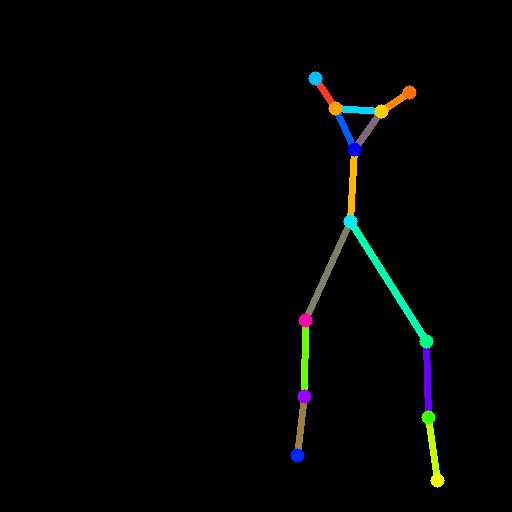

In [13]:
extract_and_decode_image(data_frame.conditioning_image[0])